In [1]:
import pybamm
import pandas as pd    # needed to read the csv data file
import matplotlib.pyplot as plt
import numpy as np

# we add our parameter_sets and functions
# from Jin2022 import *

from pathlib import Path

# <a id='toc1_'></a>[Modeling & Syst. ID - BESS](#toc0_)
*By: Dario Slaifstein, PhD Candidate*
<br> Group: DCES
<br> Project: **FLEXINet**
<br> Result: 6

Source control
- Branch: `batterySysID`
- Version: `0.1`
- Date: 13/12/2023

**Table of contents**<a id='toc0_'></a>    
- [Modeling & Syst. ID - BESS](#toc1_)    
- [Fidelity model and simulation](#toc2_)    
  - [Synthetic SANYO cell](#toc2_1_)    
  - [LFP cell](#toc2_2_)    
- [OCV testing](#toc3_)    
- [DYN testing](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

This notebook parametrizes the different models used for Li-ion batteries used in the EMS.
The BESSData class is defined in `makeEMSobjs.jl`. The class is composed by:
  - `GenInfo`: Geneneric information.
  - `PerfParameters`: Performance model.
  - `AgingParameters`: Aging model.
  - `initValue`: Initial value of the BESS [USD/kWh]

The notebook´s workflow is as follows:
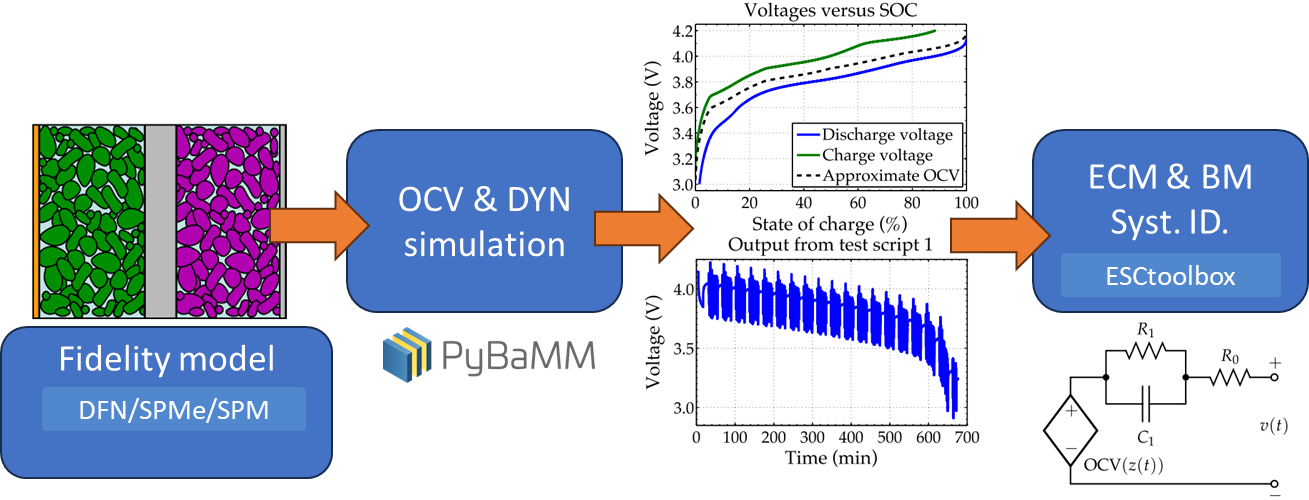

# <a id='toc2_'></a>[Fidelity model and simulation](#toc0_)
Create the DFN model

In [2]:
model = pybamm.lithium_ion.SPM()

The Doyle-Fuller-Newman model has the following Eqs.

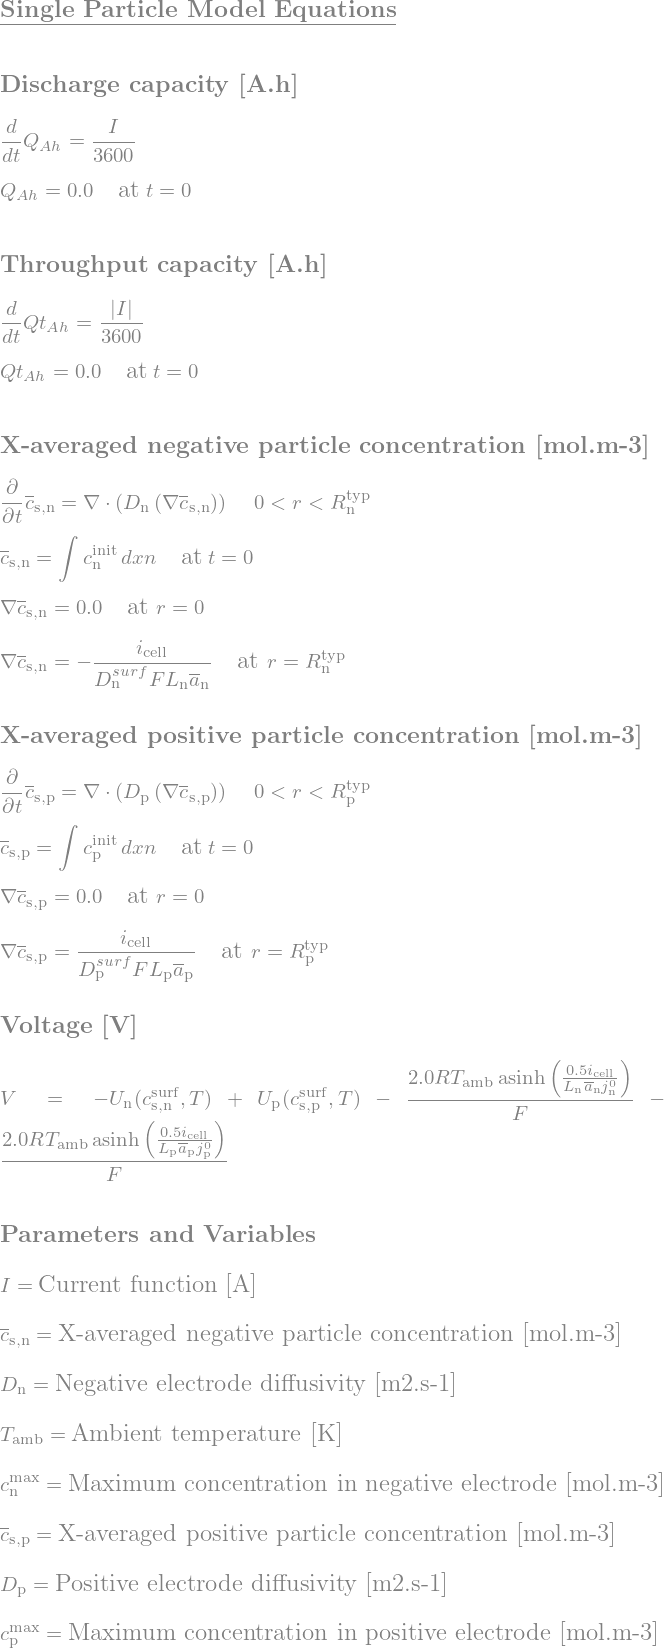

In [3]:
model.latexify()

The available data sets are:

In [4]:
list(pybamm.parameter_sets)

['Ai2020',
 'Chen2020',
 'Chen2020_composite',
 'ECM_Example',
 'Ecker2015',
 'Ecker2015_graphite_halfcell',
 'MSMR_Example',
 'Marquis2019',
 'Mohtat2020',
 'NCA_Kim2011',
 'OKane2022',
 'OKane2022_graphite_SiOx_halfcell',
 'ORegan2022',
 'Prada2013',
 'Ramadass2004',
 'Sulzer2019',
 'Xu2019']

## <a id='toc2_1_'></a>[Synthetic SANYO cell](#toc0_)
We pick the one corresponding to an NMC-G cell, which is the closest to our Sanyo cell from Jin (2022).

In [3]:
print(pybamm.parameter_sets.get_docstring("Mohtat2020"))


Parameters for a graphite/NMC532 pouch cell from the paper :footcite:t:`Mohtat2020`
and references therein.

SEI parameters are example parameters for SEI growth from the papers
:footcite:t:`Ramadass2004`, :footcite:t:`ploehn2004solvent`,
:footcite:t:`single2018identifying`, :footcite:t:`safari2008multimodal`, and
:footcite:t:`Yang2017`

SEI parameters
^^^^^^^^^^^^^^

Parameters for lithium plating are from the paper :footcite:t:`Yang2017`

.. note::
    This parameter set does not claim to be representative of the true parameter
    values. Instead these are parameter values that were used to fit SEI models to
    observed experimental data in the referenced papers.



with $Q_r$ of

In [4]:
parameter_values = pybamm.ParameterValues("Mohtat2020")
parameter_values["Nominal cell capacity [A.h]"]

5.0

In [6]:
parameter_values.search("voltage")

Lower voltage cut-off [V]	2.8
Open-circuit voltage at 0% SOC [V]	2.8
Open-circuit voltage at 100% SOC [V]	4.2
Upper voltage cut-off [V]	4.2


In [8]:
def graphite_ocp_Jin2022(sto):
    """
    Graphite Open-circuit Potential (OCP) as a function of the
    stochiometry. The fit is taken from Jin (2022) [1].

    References
    ----------
    .. [1] DOI: 10.1016/j.electacta.2021.139651
    """

    u_eq = (
        0.6379
        + 0.5416 * np.exp(-305.5309 * sto)
        + 0.0440 * np.tanh(-(sto - 0.1958) / 0.1088)
        - 0.1978 * np.tanh((sto - 1.0571) / 0.0854)
        - 0.6875 * np.tanh((sto + 0.0117) / 0.0529)
        - 0.0175 * np.tanh((sto - 0.5692) / 0.0875)
    )

    return u_eq

def graphite_diffusivity_Li2017(sto, T):
    """
    Graphite diffusivity as a function of stochiometry, in this case the
    diffusivity is taken to be a constant. The value is taken from Li, X. (2017).

    References
    ----------
    .. [1] DOI: 10.1016/j.jpowsour.2017.09.048

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    T: :class:`pybamm.Symbol`
        Dimensional temperature

    Returns
    -------
    :class:`pybamm.Symbol`
        Solid diffusivity
    """

    D_ref = 1.6 * 10 ** (-14)
    E_D_s = 42770 # CHECK
    arrhenius = np.exp(E_D_s / pybamm.constants.R * (1 / 298.15 - 1 / T))

    return D_ref * arrhenius

def NMC_diffusivity_Li2017(sto, T):
    """
    NMC diffusivity as a function of stochiometry, in this case the
    diffusivity is taken to be a constant. The value is taken from Li, X. (2017).

    References
    ----------
    .. [1] DOI: 10.1016/j.jpowsour.2017.09.048

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    T: :class:`pybamm.Symbol`
        Dimensional temperature

    Returns
    -------
    :class:`pybamm.Symbol`
        Solid diffusivity
    """

    D_ref = 1.0 * 10 ** (-14)
    E_D_s = 18550 # CHECK
    arrhenius = np.exp(E_D_s / pybamm.constants.R * (1 / 298.15 - 1 / T))

    return D_ref * arrhenius

def electrolyte_conductivity_Li2017(c_e, T):
    """
    Conductivity of LiPF6 in EC:DMC as a function of ion concentration.
    The fit is Li, X. (2017).
    
    References
    ----------
    .. [1] DOI: 10.1016/j.jpowsour.2017.09.048
    
    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte conductivity
    """

    kappa_e = 0.29
    E_k_e = 34700
    arrhenius = np.exp(E_k_e / pybamm.constants.R * (1 / 298.15 - 1 / T))

    return kappa_e * arrhenius

def electrolyte_diffusivity_Li2017(sto, T):
    """
    Diffusivity of LiPF6 in EC:DMC as a function of ion concentration. The original data
    is from [1]. The fit from Li, X. (2017).
    
    References
    ----------
    .. [1] DOI: 10.1016/j.jpowsour.2017.09.048

    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature

    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte diffusivity
    """

    D_c_e = 2.00 * 10 ** (-10)
    E_D_e = 37040 # CHECK
    arrhenius = np.exp(E_D_e / pybamm.constants.R * (1 / 298.15 - 1 / T))

    return D_c_e * arrhenius

In [9]:
parameter_values["Negative electrode OCP [V]"] = graphite_ocp_Jin2022
# Thickness of electrodes L_i
parameter_values["Negative electrode thickness [m]"] = 50.0e-6 # anode
parameter_values["Separator thickness [m]"] = 20.0e-6 # separator
parameter_values["Positive electrode thickness [m]"] = 75.0e-6 # cathode
# Particle radius R_s,i
parameter_values["Negative particle radius [m]"] = 11.0e-6 # anode
parameter_values["Positive particle radius [m]"] = 6.5e-6 # cathode
# Active material vol. fraction \varepsilon_s,i
parameter_values["Negative electrode active material volume fraction"] = 0.65 # anode
parameter_values["Positive electrode active material volume fraction"] = 0.44 # cathode

# # Electrolyte vol. fraction \varepsilon_e,i ???
# parameter_values["Negative electrode electrolyte volume fraction"] = 0.323 # anode
# parameter_values["Separator electrolyte volume fraction"] = 0.55 # separator
# parameter_values["Positive electrode electrolyte volume fraction"] = 0.46 # cathode

# # Electrode plate area ???
# parameter_values["Negative electrode plate area [m2]"] = 0.25 # anode

# Maximum solid concentration
parameter_values["Maximum concentration in negative electrode [mol.m-3]"] = 31423.0 # anode
parameter_values["Maximum concentration in positive electrode [mol.m-3]"] = 49000.0 # cathode

# # Initial state of charge ???
# parameter_values["Initial concentration in negative electrode [mol.m-3]"] = 0.8 # anode
# parameter_values["Initial concentration in positive electrode [mol.m-3]"] = 0.46 # cathode

# Electrolyte's initial concentration Ce,0
parameter_values["Initial concentration in electrolyte [mol.m-3]"] = 12000.0

# Bruggman exponent Brugg i
parameter_values["Negative electrode Bruggeman coefficient (electrode)"]=2.8
parameter_values["Negative electrode Bruggeman coefficient (electrolyte)"]=2.8
parameter_values["Positive electrode Bruggeman coefficient (electrode)"]=2.8
parameter_values["Positive electrode Bruggeman coefficient (electrolyte)"]=2.8
parameter_values["Separator Bruggeman coefficient (electrolyte)"]=2.8

# Solid-electrolyte interface resistance ???
parameter_values["Contact resistance [Ohm]"]=0.029 # in the paper the unit is [Ohm/s] not [Ohm]
# CHECK GEOMETRY

# Solid phase Li+ diffusion
parameter_values["Negative electrode diffusivity [m2.s-1]"] = graphite_diffusivity_Li2017
parameter_values["Positive electrode diffusivity [m2.s-1]"] = NMC_diffusivity_Li2017

# Electrolyte Li+ diffusion
parameter_values["Electrolyte diffusivity [m2.s-1]"] = electrolyte_diffusivity_Li2017

# Conductivity of electrolyte
parameter_values["Electrolyte conductivity [S.m-1]"] = electrolyte_conductivity_Li2017

# Conductivity of solid phase
parameter_values["Positive electrode conductivity [S.m-1]"]	= 10

# # Reaction rate constant ??
# parameter_values["Negative electrode reaction rate constant [Am2.5/m1.5]"] = 8.80e-11
# parameter_values["Positive electrode reaction rate constant [Am2.5/m1.5]"] = 5.80e-11

# Transference number
parameter_values["Cation transference number"] = 0.363

# activity coefﬁcient b ??
# parameter_values["activity coefﬁcient"] = 1.5

**Note:**
Remember that the [DFN](https://docs.pybamm.org/en/stable/source/examples/notebooks/models/DFN.html) is a 1D model thus it is not necessary to define a geometry because its PDEs and boundary conditions are independent of the coordinate system. Of course, this is a simplification and in the future we should change to the [Jelly roll model](https://docs.pybamm.org/en/stable/source/examples/notebooks/models/jelly-roll-model.html).

## <a id='toc2_2_'></a>[LFP cell](#toc0_)
Besides the Sanyo cell, we will also simulate an A123 LFP/G cell from [Prada (2013)](https://iopscience.iop.org/article/10.1149/2.053304jes). We might have to modify the `paramater_set` to adapt it to the 2.3-Ah 26650 LFP cell from [Jin (2017)](https://linkinghub.elsevier.com/retrieve/pii/S037877531631802X).

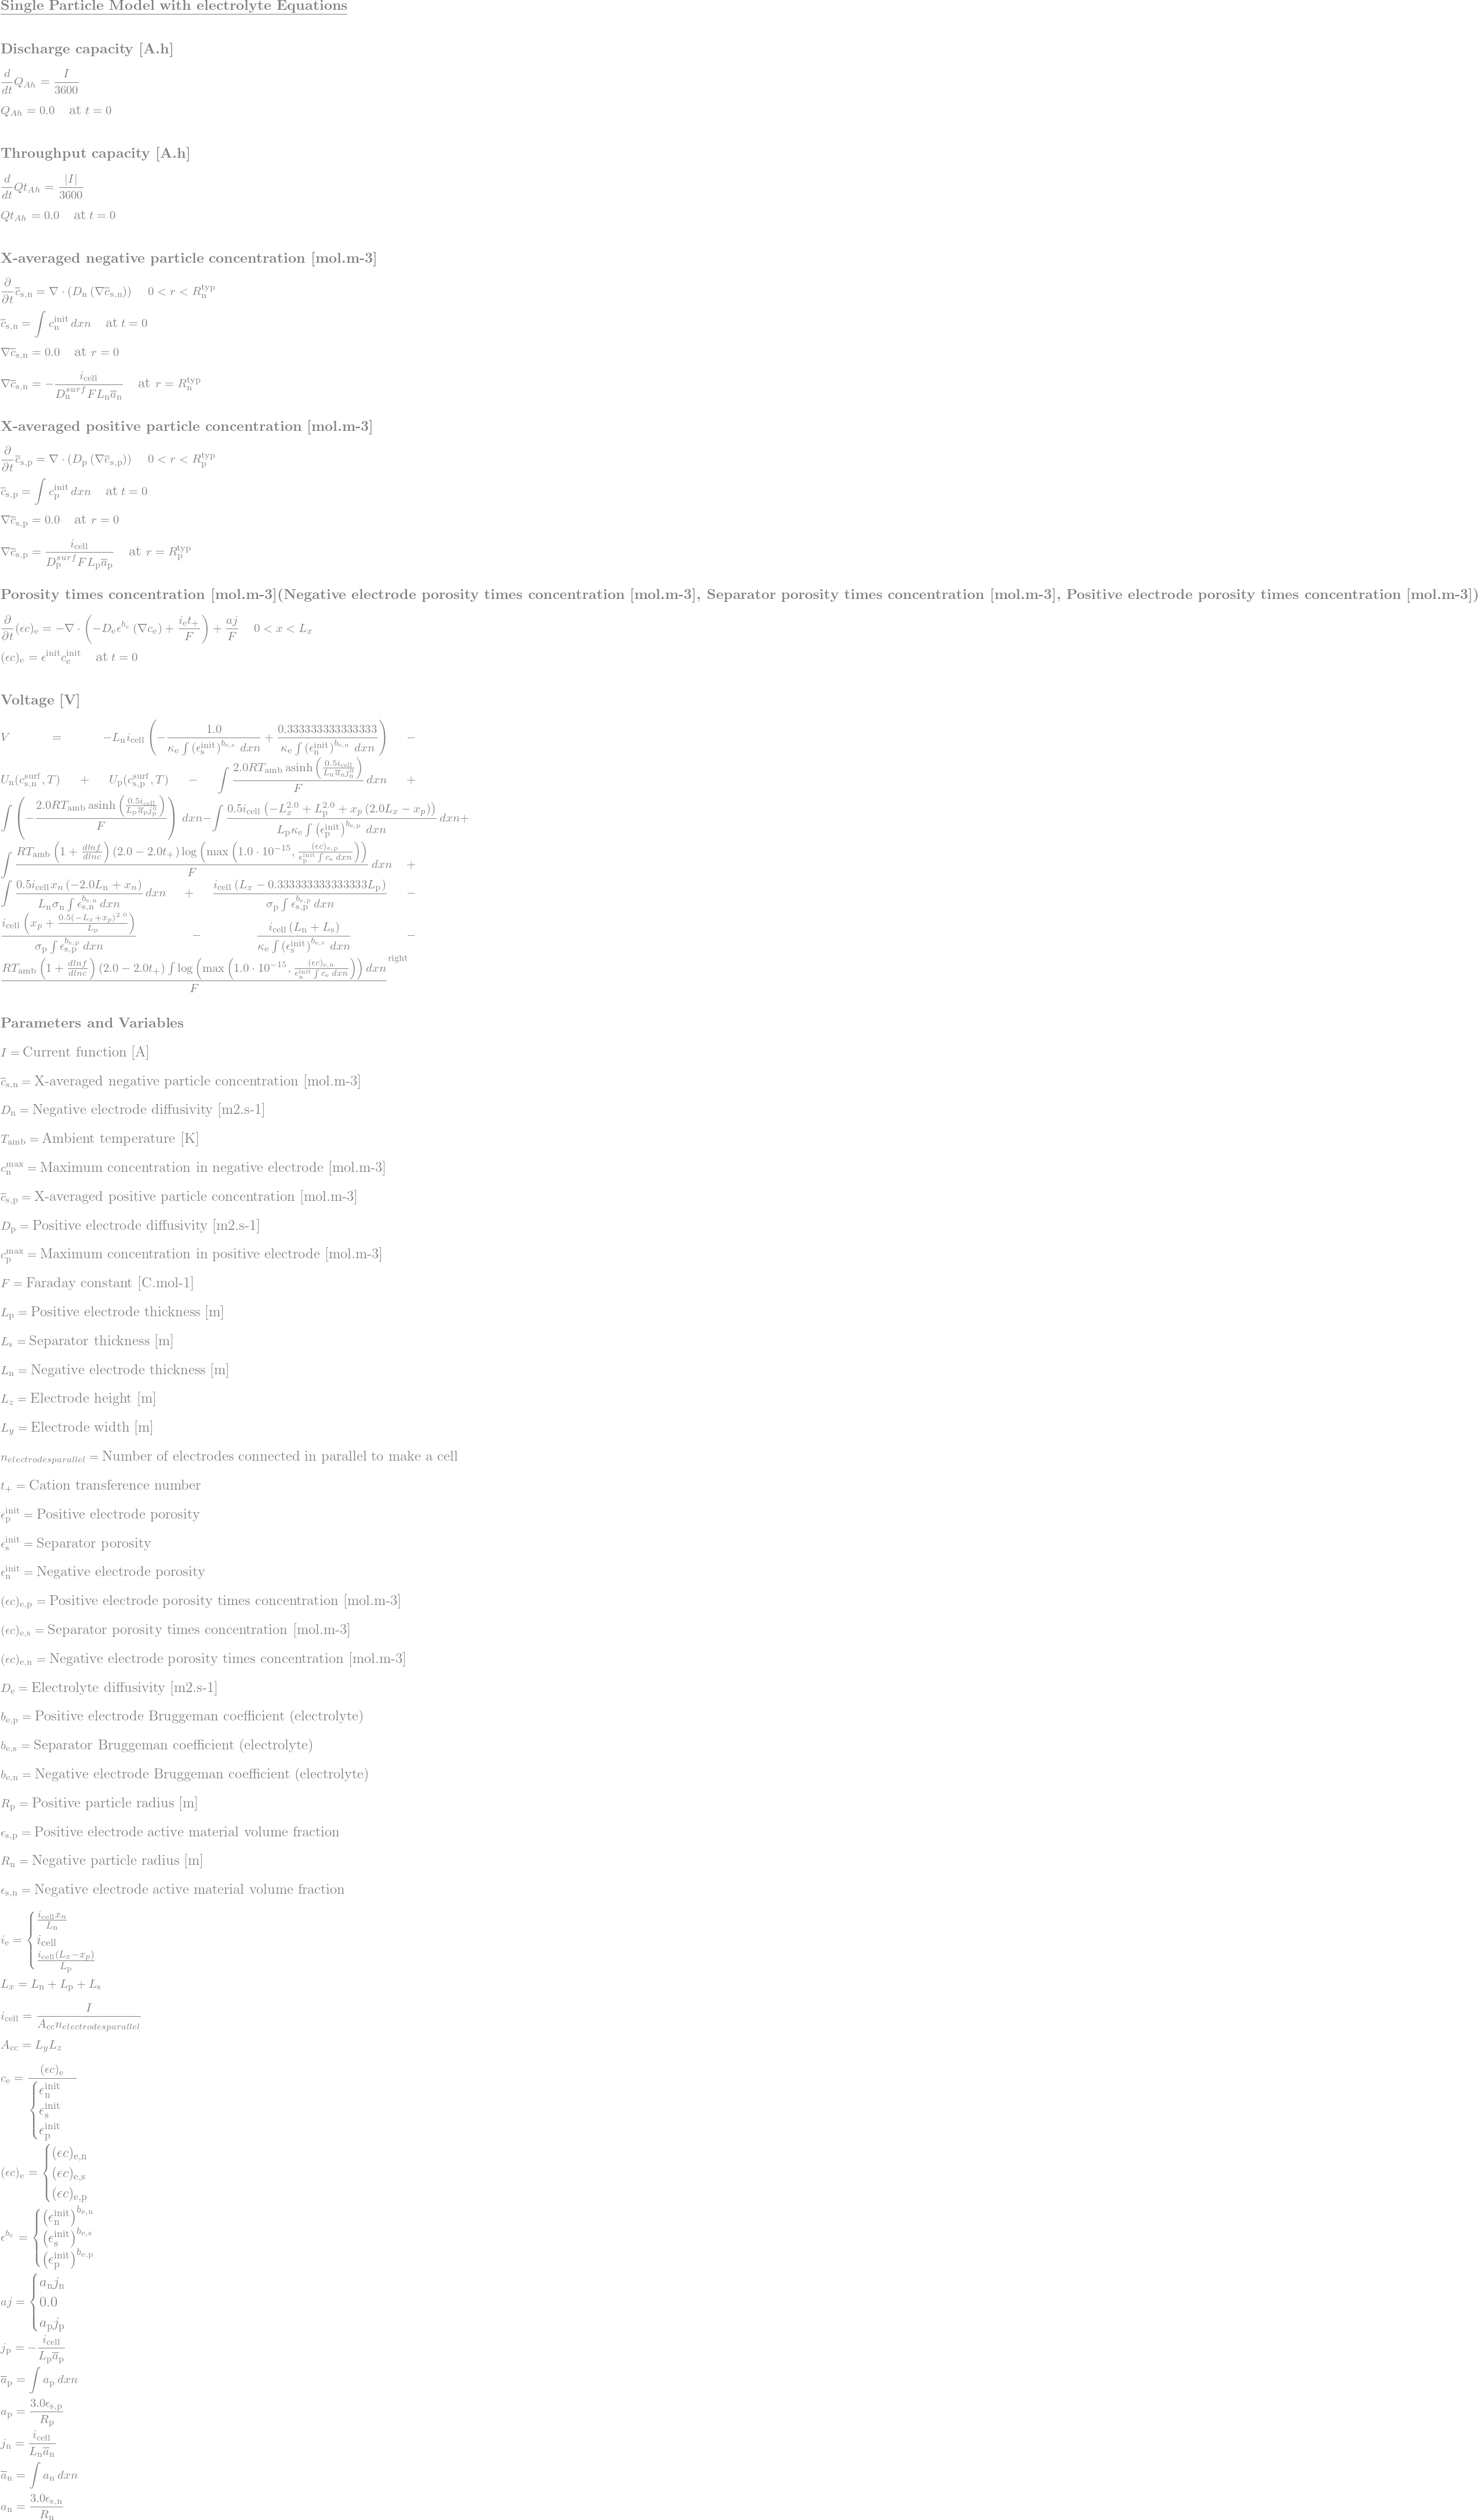

In [3]:
model = pybamm.lithium_ion.SPMe()
parameter_values = pybamm.ParameterValues("Prada2013")
model.latexify()

In [5]:
parameter_values = pybamm.ParameterValues("Prada2013")
x0, x100, y100, y0 = pybamm.lithium_ion.get_min_max_stoichiometries(parameter_values)
print(x0, x100, y100, y0)

0.017619411644243348 0.8100363695199028 0.003767884398705004 0.703500714165226


In [4]:
print(pybamm.parameter_sets.get_docstring("Prada2013"))


Parameters for an LFP cell, from the paper :footcite:t:`Prada2013`



In [5]:
parameter_values["Nominal cell capacity [A.h]"]

In [6]:
parameter_values.search("voltage")

Lower voltage cut-off [V]	2.0
Open-circuit voltage at 0% SOC [V]	2.0
Open-circuit voltage at 100% SOC [V]	3.6
Upper voltage cut-off [V]	3.6


# <a id='toc3_'></a>[OCV testing](#toc0_)
As per Plett (2015)

In [10]:
OCVexperiment_S1 = pybamm.Experiment(
    [
        (   
            "Rest for 1 hour",
            "Discharge at C/30 until 2.0V",
            "Rest for 15 minutes",
        ),
    ]
)

OCVexperiment_S2 = pybamm.Experiment(
    [
        (   
            "Rest for 2 hour",
            "Discharge at C/30 until 2.0V",
            "Rest for 15 minutes",
        ),
    ]
)

OCVexperiment_S3 = pybamm.Experiment(
    [
        (   
            # "Charge at 1C until 100% SOC",
            "Rest for 2 hour",
            "Charge at C/30 until 3.6V",
            "Rest for 15 minutes",
        ),
    ]
)

OCVexperiment_S4 = pybamm.Experiment(
    [
        (   
            # "Charge at 1C until 100% SOC",
            "Rest for 2 hour",
            "Charge at C/30 until 3.6V",
            "Rest for 1 hour",
        ),
    ]
)
experiments = [
    OCVexperiment_S1,
    OCVexperiment_S2,
    OCVexperiment_S3,
    OCVexperiment_S4]

In [11]:
# Initialize the model
cellID = "SYNSANYO"
outVars = ["Time [s]", "Time [h]","Current [A]","Voltage [V]"]
i = 1
# Pre-charge the cell with a CC-CV
experiment_CCCV = pybamm.Experiment(
    ["Charge at 1 A until 3.8 V", "Hold at 3.8 V until C/30"]
)
sim_cccv = pybamm.Simulation(model, parameter_values=parameter_values,
                             experiment=experiment_CCCV, solver=pybamm.CasadiSolver())
sol_cccv = sim_cccv.solve() # store the init cond of the test.
OCV_sol=[]
model.set_initial_conditions_from(sol_cccv, inplace=True)
# loop over scripts 1 to 4
for experiment in experiments:
    sim = pybamm.Simulation(model, parameter_values=parameter_values,
                            experiment=experiment, solver=pybamm.CasadiSolver())
    solv0 = sim.solve()
    OCV_sol.append(sim.solution)
    OCVpath = f'../data/input/cell_models/{cellID}_OCV_P25_S{i}.csv'
    OCV_sol[i-1].save_data(OCVpath, outVars, to_format="csv")
    i += 1
    model.set_initial_conditions_from(solv0, inplace=True)

The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
At t = 41.4343 and h = 3.077e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 41.4343 and h = 1.15609e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 41.4343 and h = 9.71211e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 41.4343 and h = 2.68382e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 3.93414 and h = 6.54818e-16, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 3.93428 and h = 5.31951e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 3.9341 and h = 1.45e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 3.93426 and h = 1.11267e-12, the corrector convergence failed repeatedly or wit

In [12]:
outVars = ["Current [A]","Voltage [V]"]
OCV_sol[0].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=16.428073896708682, step=0.1642807389670868)…

In [13]:
OCV_sol[1].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=2.0, step=0.02), Output()), _dom_classes=('w…

In [11]:
OCV_sol[2].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=32.17419845127252, step=0.3217419845127252),…

In [12]:
OCV_sol[3].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=3.002874885955405, step=0.030028748859554047…

We have to add a couple of variables to the `.csv` file:
- `Discharge_Capacity(Ah)`
- `Charge_Capacity(Ah)`
- `Step_Index`

In [16]:
for i in range(1,5):
    csvdata = f'../data/input/cell_models/{cellID}_OCV_P25_S{i}.csv'
    df = pd.read_csv(csvdata)
    # add new variables columns = ['Discharge_Capacity(Ah)', 'Charge_Capacity(Ah)', 'Step_Index', 'Voltage(V)']
    # The Discharge capacity is the integral of the 'Current [A]' column when the current is positive
    # initialize the new vars
    disI = np.zeros(len(df))
    chgI = np.zeros(len(df))
    idx = df['Current [A]'] > 0
    disI[idx] = df['Current [A]'][idx]
    chgI[~idx] = -df['Current [A]'][~idx] # in the other case, the current is negative
    disChg = np.cumsum(disI) * df['Time [h]'].iloc[1]
    chgChg = np.cumsum(chgI) * df['Time [h]'].iloc[1]
    # assign vars to cols
    df['Discharge_Capacity(Ah)'] = disChg
    df['Charge_Capacity(Ah)'] = chgChg
    # modify the step index
    df['Step'] = df['Step'] + 1
    # change the headers
    df.rename(columns={'Step': 'Step_Index','Time [s]': 'Step_Time(s)','Time [h]': 'Time(h)',
                       'Current [A]': 'Current(A)', 'Voltage [V]': 'Voltage(V)'}, inplace=True)
    df.to_csv(csvdata)
df

,Step_Time(s),Time(h),Current(A),Voltage(V),Cycle,Step_Index,Discharge_Capacity(Ah),Charge_Capacity(Ah)
0,0.000000,0.000000,0.0,3.588431,0.0,1.0,0.0,-0.000000
1,60.000000,0.016667,0.0,3.588431,0.0,1.0,0.0,-0.000000
2,120.000000,0.033333,0.0,3.588431,0.0,1.0,0.0,-0.000000
3,180.000000,0.050000,0.0,3.588431,0.0,1.0,0.0,-0.000000
4,240.000000,0.066667,0.0,3.588431,0.0,1.0,0.0,-0.000000
...,...,...,...,...,...,...,...,...
179,10570.349589,2.936208,0.0,3.591188,0.0,3.0,0.0,0.002556
180,10630.349589,2.952875,0.0,3.591188,0.0,3.0,0.0,0.002556
181,10690.349589,2.969542,0.0,3.591188,0.0,3.0,0.0,0.002556
182,10750.349589,2.986208,0.0,3.591188,0.0,3.0,0.0,0.002556


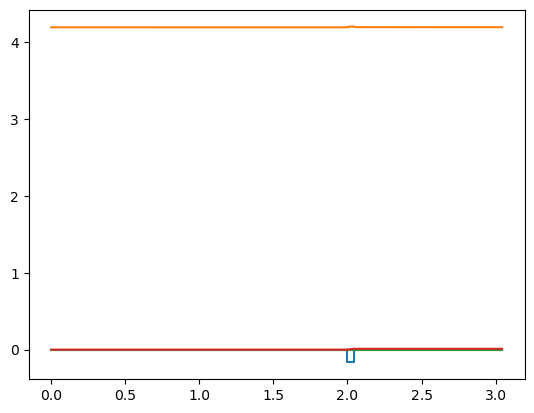

In [21]:
plt.plot(df['Time(h)'], df['Current(A)'])
plt.plot(df['Time(h)'], df['Voltage(V)'])
plt.plot(df['Time(h)'], df['Discharge_Capacity(Ah)'])
plt.plot(df['Time(h)'], df['Charge_Capacity(Ah)'])

We plot now the `Average negative particle stoichiometry`, $z$, which is non-other than the battery $SoC$

In [ ]:
z = OCVtest["Average negative particle stoichiometry"].entries
t = OCVtest["Time [h]"].entries
fig = plt.figure(figsize=(5,3))
plt.plot(t, z, label='z')
plt.grid()
plt.xlabel('t [hr]')
# plt.ylim(top=2000, bottom=0)
plt.title('OCV test')
plt.legend()

# <a id='toc4_'></a>[DYN testing](#toc0_)
As per Plett (2015)

Define the experiments

In [10]:
# Import drive cycle from file
path=f"../data/input/drive_cycles/UDDS.csv"
drive_cycle_current = pd.read_csv(path, comment="#", header=None).to_numpy()
drive_cycle_current[:,1] = drive_cycle_current[:, 1] * 1.1

DYNexperiment_S1 = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Discharge at 1C for 5 minutes",
        ),
    ]+
    [ # Cycle cell with the driving cycle
        (
            pybamm.step.current(drive_cycle_current),
            "Rest for 15 minutes",
        ),
    ] * 8
)

DYNexperiment_S2 = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Discharge at C/30 until 2.0V",
            # pybamm.step.current(drive_cycle_current), # dither profile
        )
    ]
)

DYNexperiment_S3 = pybamm.Experiment(
    [
        (
            "Charge at 1C until 3.6V",
            "Hold at 3.6 V until C/30",
            # pybamm.step.current(drive_cycle_current), # dither profile
        )
    ]
)

experiments = [
    DYNexperiment_S1,
    DYNexperiment_S2,
    DYNexperiment_S3]

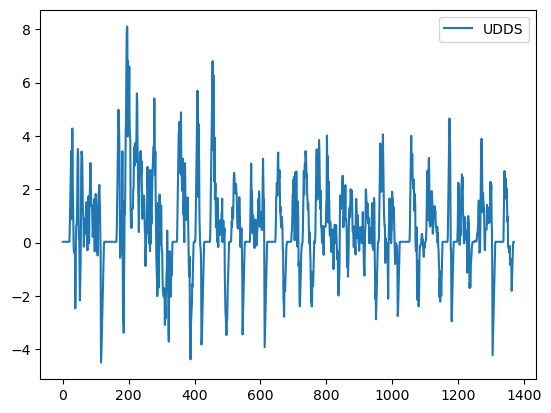

In [4]:
plt.plot(drive_cycle_current[:,0],drive_cycle_current[:,1], label="UDDS")
plt.legend()

Simulate

In [11]:
# Initialize the model
outVars = ["Time [s]", "Time [h]","Current [A]","Voltage [V]"]
cellID = "SYNLFP"
i = 1
# Pre-charge the cell with a CC-CV
experiment_CCCV = pybamm.Experiment(
    [("Charge at C/2 until 3.6 V", "Hold at 3.6 V until C/30")]
)
sim_cccv = pybamm.Simulation(model, parameter_values=parameter_values, experiment=experiment_CCCV)
sol_cccv = sim_cccv.solve(initial_soc=0.5) # store the init cond of the test.
DYN_sol=[]
model.set_initial_conditions_from(sol_cccv, inplace=True)
# loop over scripts 1 to 3
for experiment in experiments:
    sim = pybamm.Simulation(model, parameter_values=parameter_values,
                            experiment=experiment, solver=pybamm.CasadiSolver(dt_max=60, return_solution_if_failed_early=True))
    solv0 = sim.solve()
    DYN_sol.append(sim.solution)
    DYNpath = f'../data/input/cell_models/{cellID}_DYN_8_P25_S{i}.csv'
    DYN_sol[i-1].save_data(DYNpath, outVars, to_format="csv")
    i += 1
    model.set_initial_conditions_from(solv0, inplace=True)

In [12]:
outVars = ["Current [A]","Voltage [V]"]
DYN_sol[0].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=6.125555555555556, step=0.061255555555555556…

In [13]:
DYN_sol[1].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=2.339458034868071, step=0.02339458034868071)…

In [14]:
DYN_sol[2].plot(output_variables=outVars)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0324081980174948, step=0.01032408198017494…

We need to add the charged and discharged capacity $Q_{\textrm{chg/dis},t}$ to the output `.csv`. They are calculated as:
\begin{equation}
    i_{\textrm{chg},t} = \begin{cases}
      i_t, & \text{if}\ i_t < 1 \\
      0, & \text{otherwise}
    \end{cases}
\end{equation}

\begin{equation}
    i_{\textrm{dis},t} = \begin{cases}
      i_t, & \text{if}\ i_t > 1 \\
      0, & \text{otherwise}
    \end{cases}
\end{equation}

\begin{equation}
    Q_{\textrm{chg/dis},t} = \int{i_{\textrm{chg/dis},t}.\Delta t}
\end{equation}

In [15]:
for i in range(1,4):
    csvdata = f'../data/input/cell_models/{cellID}_DYN_8_P25_S{i}.csv'
    df = pd.read_csv(csvdata)
    # add new variables columns = ['Discharge_Capacity(Ah)', 'Charge_Capacity(Ah)', 'Step_Index', 'Voltage(V)']
    # The Discharge capacity is the integral of the 'Current [A]' column when the current is positive
    disI = np.zeros(len(df))
    chgI = np.zeros(len(df))
    idis = np.where(df['Current [A]'] > 0)
    ichg = np.where(df['Current [A]'] < 0)
    disI[idis] = df['Current [A]'].iloc[idis]
    chgI[ichg] = -df['Current [A]'].iloc[ichg] # in the other case, the current is negative
    disChg = np.cumsum(disI[1::] * np.diff(df['Time [h]']))
    chgChg = np.cumsum(chgI[1::] * np.diff(df['Time [h]']))
    # assign vars to cols
    df[' disAh'] = np.append(0,disChg)
    df[' chgAh'] = np.append(0,chgChg)
    # modify the step index
    df['Step'] = df['Step'] + 1

    # change the headers
    df.rename(columns={'Step': ' step','Time [s]': ' time','Time [h]': ' Time(h)',
                       'Current [A]': ' current', 'Voltage [V]': ' voltage'}, inplace=True)
    df.to_csv(csvdata)
df

,time,Time(h),current,voltage,Cycle,step,disAh,chgAh
0,0.000000,0.000000,-2.300000,2.144982,0.0,1.0,0.0,0.000000
1,60.000000,0.016667,-2.300000,3.018260,0.0,1.0,0.0,0.038333
2,120.000000,0.033333,-2.300000,3.117524,0.0,1.0,0.0,0.076667
3,180.000000,0.050000,-2.300000,3.194141,0.0,1.0,0.0,0.115000
4,240.000000,0.066667,-2.300000,3.236903,0.0,1.0,0.0,0.153333
...,...,...,...,...,...,...,...,...
60,3541.196916,0.983666,-2.300000,3.599989,0.0,1.0,0.0,2.262431
61,3541.196916,0.983666,-2.300414,3.600000,0.0,2.0,0.0,2.262431
62,3601.196916,1.000332,-0.603418,3.600000,0.0,2.0,0.0,2.272488
63,3661.196916,1.016999,-0.208731,3.600000,0.0,2.0,0.0,2.275967


Awesome, now the tests are processed using the [ESCtoolbox-python](https://github.com/batterysim/esctoolbox-python/tree/master) and the ECM model is stored in `SYNSANYO-modeldyn-no-hys.json`.